<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-23-binning-binarization-in-sklearn?scriptVersionId=341163899" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 23 — Binning & Binarization in Scikit-learn

### **Transform Continuous Features into Meaningful Categories using `KBinsDiscretizer`**

---

# 🚀 Introduction

Many Machine Learning algorithms perform better when continuous numerical features are grouped into meaningful intervals (bins).

This process is called **Binning** (or **Discretization**).

Instead of using raw numerical values like:

```
Age
23
25
26
27
28
```

we convert them into categories:

```
Young
Young
Adult
Adult
Adult
```

This reduces noise, handles outliers, and can improve model performance.

In this notebook, we'll learn how to perform feature binning using Scikit-learn's `KBinsDiscretizer`.


---

# 📦 Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import Binarizer
from sklearn.compose import ColumnTransformer

---

# 📂 Load Dataset

We'll use the California Housing dataset.




In [2]:
df = pd.read_csv("/kaggle/input/datasets/ahmedfakhar123/titanic-survival-dataset/Titanic_Survival_Dataset.csv",
                usecols=['Age','Fare','SibSp','Parch','Survived'])
df

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500
...,...,...,...,...,...
886,0,27.0,0,0,13.0000
887,1,19.0,0,0,30.0000
888,0,NaN,1,2,23.4500
889,1,26.0,0,0,30.0000



---

# 📊 Dataset Overview



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Parch     891 non-null    int64  
 4   Fare      891 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 34.9 KB


In [4]:
df.describe()

,Survived,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df['Family'] = df['SibSp'] + df['Parch']
df.head()

,Survived,Age,SibSp,Parch,Fare,Family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


In [6]:
df.drop(columns=['SibSp','Parch'],inplace=True)
df.head()

,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0



---

# 🎯 Select Features


In [7]:
X = df[[
    "Age",
    "Fare",
    "Family"
]]

y = df["Survived"]

---

# ✂️ Train Test Split


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=41
)

In [9]:
X_train["Age"] = X_train["Age"].fillna(X_train["Age"].median())
X_test["Age"] = X_test["Age"].fillna(X_train["Age"].median())

---

# 📈 Original Distribution


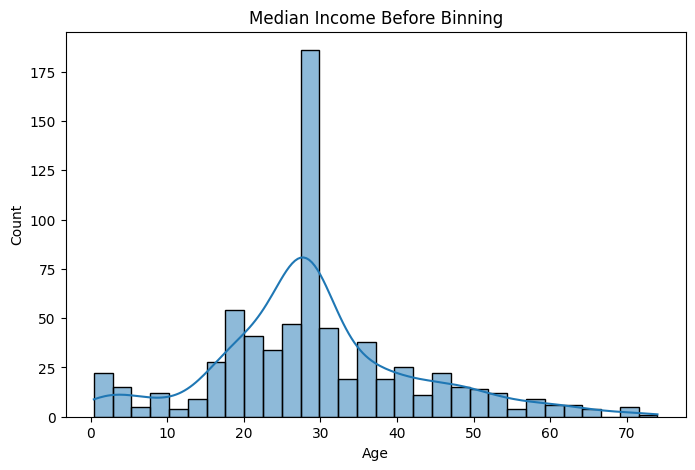

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    X_train["Age"],
    kde=True,
    bins=30
)

plt.title("Median Income Before Binning")
plt.show()

In [11]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [12]:
accuracy_score(y_test, y_pred)

0.6480446927374302

In [13]:
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy'))

np.float64(0.6453308364544319)

---

# 📦 Step 1: What is Binning?

Binning converts continuous values into fixed intervals.

Example:

| Income | Bin    |
| ------ | ------ |
| 1.2    | Low    |
| 3.1    | Medium |
| 7.5    | High   |


---

# 🔹 Equal Width Binning

Equal Width divides the feature into intervals of equal size.


In [14]:
equal_width = KBinsDiscretizer(
    n_bins=10,
    encode="ordinal",
    strategy="uniform"
)

X_train_uniform = equal_width.fit_transform(X_train[["Age", "Fare"]])
X_test_uniform = equal_width.transform(X_test[["Age", "Fare"]])

---

# 📊 Visualize Equal Width Bins


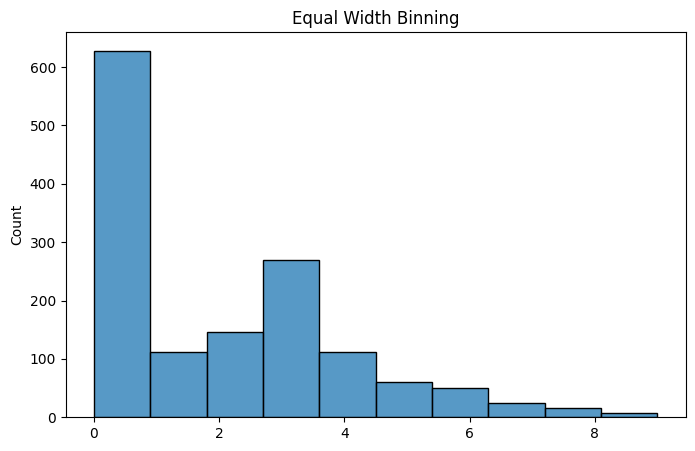

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    X_train_uniform.flatten(),
    bins=10
)

plt.title("Equal Width Binning")
plt.show()

---

# 🔹 Quantile Binning

Each bin contains nearly the same number of observations.


In [16]:
quantile = KBinsDiscretizer(
    n_bins=4,
    encode="ordinal",
    strategy="quantile"
)

X_train_quantile = quantile.fit_transform(X_train[["Age", "Fare"]])
X_test_quantile = quantile.transform(X_test[["Age", "Fare"]])

---

# 📊 Visualize Quantile Bins


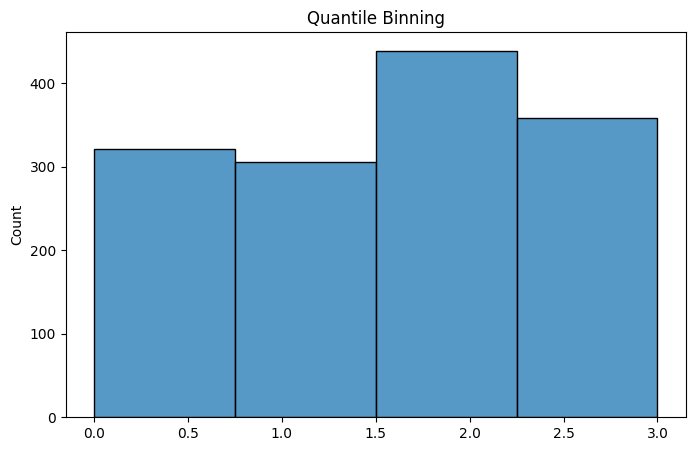

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    X_train_quantile.flatten(),
    bins=4
)

plt.title("Quantile Binning")
plt.show()

---

# 🔹 KMeans Binning

Creates bins based on clustering.


In [18]:
kmeans = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="kmeans"
)

X_train_kmeans = kmeans.fit_transform(X_train[["Age", "Fare"]])
X_test_kmeans = kmeans.transform(X_test[["Age", "Fare"]])

---

# 📊 Visualize KMeans Bins



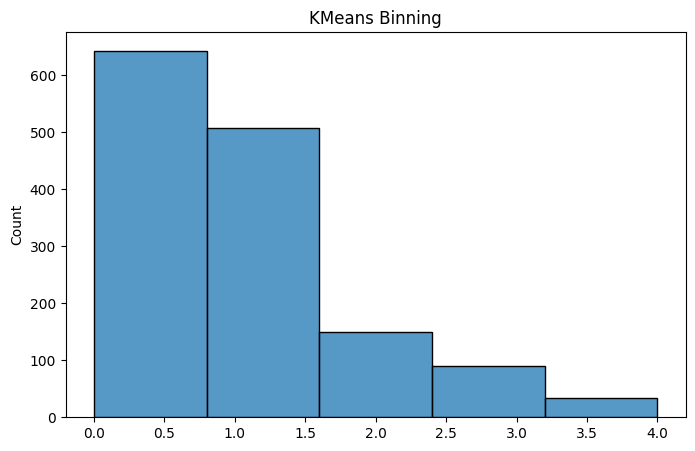

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    X_train_kmeans.flatten(),
    bins=5
)

plt.title("KMeans Binning")
plt.show()

In [20]:
def discretize(bins, strategy):
    kbin = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    
    trf = ColumnTransformer([
        ('first', kbin, [0, 1]),
    ])
    
    X_trf = trf.fit_transform(X_train)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X, y ,cv=10, scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X_train['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X_train['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6464669163545568


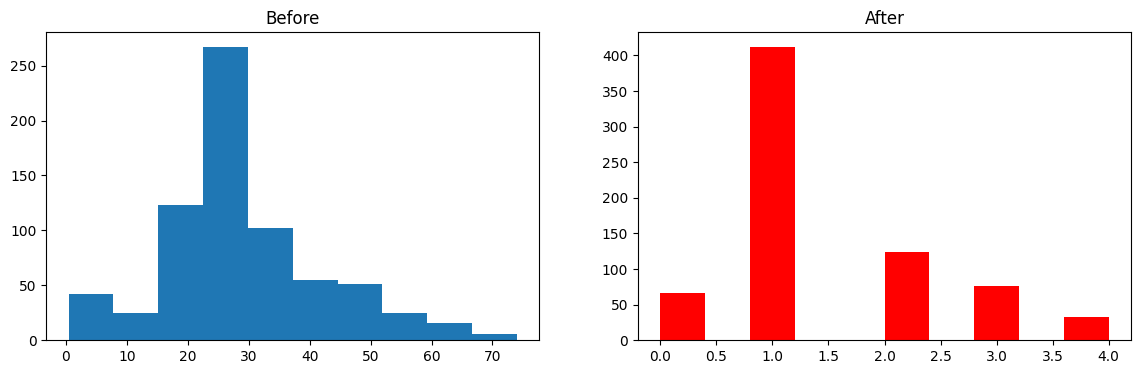

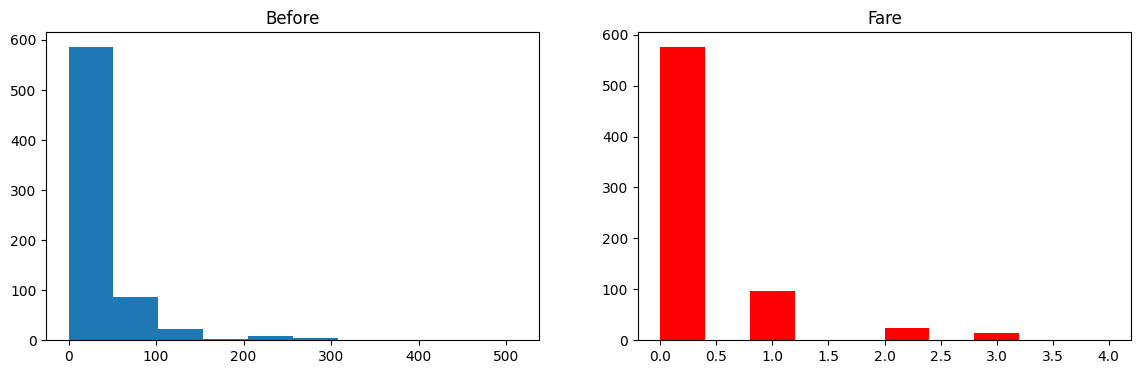

In [21]:
discretize(5,'kmeans')

---

# 📊 Compare Binning Strategies

| Strategy | Description                     | Best For                |
| -------- | ------------------------------- | ----------------------- |
| Uniform  | Equal-width intervals           | Evenly distributed data |
| Quantile | Equal number of samples per bin | Skewed data             |
| KMeans   | Cluster-based intervals         | Complex distributions   |

---

# 💡 When Should You Use Binning?

Use Binning when:

* 📈 Numerical features have a wide range.
* 🎯 You want to reduce noise.
* 📦 Features contain outliers.
* 🌳 You're using interpretable models.
* 🤖 Creating new categorical features.

Avoid Binning when:

* Data is already well distributed.
* Fine-grained numerical precision is important.

---

# 🎯 Advantages

✅ Reduces noise

✅ Handles outliers

✅ Simplifies complex features

✅ Improves interpretability

✅ Can improve model performance


---

# ⚫ Step 2: What is Binarization?

Binarization transforms numerical features into binary values (**0** or **1**) using a predefined threshold.

Example:

| Exam Score | Passed |
| ---------- | ------ |
| 42 | 0 |
| 55 | 1 |
| 68 | 1 |
| 38 | 0 |

> **Threshold = 50**

In [22]:
binarize = Binarizer(copy=False)

X_train_binarize = binarize.fit_transform(X_train[["Family"]])
X_test_binarize = binarize.transform(X_test[["Family"]])

In [23]:
X_train["Family"] = X_train_binarize

pd.DataFrame(X_train, columns=['Family', 'Age', 'Fare'])

,Family,Age,Fare
628,0,26.0,7.8958
300,0,28.0,7.7500
663,0,36.0,7.4958
50,1,7.0,39.6875
846,1,28.0,69.5500
...,...,...,...
407,1,3.0,18.7500
601,0,28.0,7.8958
243,0,22.0,7.1250
321,0,27.0,7.8958


---
# 🎉 Conclusion

In this notebook, we explored **Binning** and **Binarization**, two important feature engineering techniques used to transform numerical data into more meaningful representations.

We learned how to convert continuous features into discrete intervals using **Uniform**, **Quantile**, and **K-Means** binning with `KBinsDiscretizer`, and how to transform numerical values into binary features using Scikit-learn's `Binarizer`. These techniques can improve feature interpretability, reduce the impact of outliers, and enhance the performance of certain machine learning models when applied appropriately.

---
## 🚀 What’s Next?

In the next notebook, we’ll move beyond basic missing-value techniques like **Simple Imputer** and explore more advanced approaches for filling missing data.

[**🤖 ML 24 — KNN Imputer & Iterative Imputer**](https://www.kaggle.com/code/ahmedfakhar123/ml-24-knn-imputer-iterative-imputer)

We’ll cover:

* 🔹 **KNN Imputer** — imputing missing values using the nearest similar observations.
* 🔹 **Iterative Imputer** — estimating missing values by modeling each feature using the other available features.
* 🔹 **KNN vs Iterative Imputation** — understanding when each technique is useful.
* 🔹 **Practical implementation in Scikit-learn**
* 🔹 **Evaluating how different imputation methods affect ML models**

These techniques are especially useful when simply replacing missing values with the **mean, median, or most frequent value** may not preserve the relationships between features.

**Next up:** 🚀 *Smarter ways to handle missing data with KNN and Iterative Imputation.*
